In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

df = pd.read_csv("../data/cme_dataset.csv", parse_dates=["cme_time"])
df.head()

,cme_time,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type_num,cme_id,flare_class,flare_class_num,flare_log_peak_flux,...,wind_density_mean,wind_pressure_mean,wind_efield_mean,wind_temp_mean,ctx_f107,ctx_sunspots,kp_max_post,storm,storm_attributed,storm_attributed_v2
0,2017-02-10 13:48:00,594.0,10.0,18.0,148.0,2.0,0,NaN,NaN,NaN,...,5.500000,2.005278,0.243889,70931.944444,72.027778,22.555556,2.3,0,0,0
1,2017-02-11 06:00:00,456.0,18.0,-1.0,93.0,1.0,1,NaN,NaN,NaN,...,4.745946,1.616486,0.265946,56423.216216,72.972973,23.486486,2.3,0,0,0
2,2017-02-15 03:09:00,405.0,12.0,16.0,-173.0,1.0,2,NaN,NaN,NaN,...,12.597222,2.053611,0.010000,18074.472222,72.833333,19.555556,4.3,0,0,0
3,2017-02-18 02:30:00,239.0,17.0,26.0,-110.0,1.0,3,B,1.0,-6.885685,...,6.983333,3.387500,0.509722,149947.583333,73.675000,13.583333,3.7,0,0,0
4,2017-02-18 07:24:00,492.0,27.0,4.0,88.0,1.0,4,NaN,NaN,NaN,...,6.444444,3.187778,0.266111,137876.500000,73.966667,13.444444,3.7,0,0,0


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDate range:")
print(df["cme_time"].min(), "to", df["cme_time"].max())

print("\nTarget balance:")
print(df["storm"].value_counts())
print("Storm percent:", round(df["storm"].mean() * 100, 2), "%")

Dataset shape: (4734, 30)

Columns:
['cme_time', 'cme_speed_kms', 'cme_half_angle_deg', 'cme_latitude', 'cme_longitude', 'cme_type_num', 'cme_id', 'flare_class', 'flare_class_num', 'flare_log_peak_flux', 'flare_duration_min', 'flare_end_time_imputed', 'has_flare', 'wind_bz_mean', 'wind_bz_min', 'wind_bz_south_frac', 'wind_bz_strong_south_frac', 'wind_imf_mean', 'wind_speed_mean', 'wind_speed_max', 'wind_density_mean', 'wind_pressure_mean', 'wind_efield_mean', 'wind_temp_mean', 'ctx_f107', 'ctx_sunspots', 'kp_max_post', 'storm', 'storm_attributed', 'storm_attributed_v2']

Date range:
2017-02-10 13:48:00 to 2024-12-29 18:24:00

Target balance:
storm
0    3655
1    1079
Name: count, dtype: int64
Storm percent: 22.79 %


In [ ]:
# Feature columns and target
FEATURE_COLS = [
    "cme_speed_kms",
    "cme_half_angle_deg",
    "cme_latitude",
    "cme_longitude",
    "cme_type_num",
    "flare_class_num",
    "flare_log_peak_flux",
    "flare_duration_min",
    "flare_end_time_imputed",
    "has_flare",
    "wind_bz_mean",
    "wind_bz_min",
    "wind_bz_south_frac",
    "wind_bz_strong_south_frac",
    "wind_imf_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_density_mean",
    "wind_pressure_mean",
    "wind_efield_mean",
    "wind_temp_mean",
    "ctx_f107",
    "ctx_sunspots",
]

TARGET_COL = "storm"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print("Number of features:", len(FEATURE_COLS))
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Number of features: 23
X shape: (4734, 23)
y shape: (4734,)


,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type_num,flare_class_num,flare_log_peak_flux,flare_duration_min,flare_end_time_imputed,has_flare,...,wind_bz_strong_south_frac,wind_imf_mean,wind_speed_mean,wind_speed_max,wind_density_mean,wind_pressure_mean,wind_efield_mean,wind_temp_mean,ctx_f107,ctx_sunspots
0,594.0,10.0,18.0,148.0,2.0,NaN,NaN,NaN,NaN,0,...,0.0,4.672222,421.194444,445.0,5.500000,2.005278,0.243889,70931.944444,72.027778,22.555556
1,456.0,18.0,-1.0,93.0,1.0,NaN,NaN,NaN,NaN,0,...,0.0,3.610811,411.972973,440.0,4.745946,1.616486,0.265946,56423.216216,72.972973,23.486486
2,405.0,12.0,16.0,-173.0,1.0,NaN,NaN,NaN,NaN,0,...,0.0,2.861111,307.750000,322.0,12.597222,2.053611,0.010000,18074.472222,72.833333,19.555556
3,239.0,17.0,26.0,-110.0,1.0,1.0,-6.885685,31.0,0.0,1,...,0.0,6.061111,495.444444,536.0,6.983333,3.387500,0.509722,149947.583333,73.675000,13.583333
4,492.0,27.0,4.0,88.0,1.0,NaN,NaN,NaN,NaN,0,...,0.0,6.077778,500.361111,536.0,6.444444,3.187778,0.266111,137876.500000,73.966667,13.444444


In [5]:
# Time-based train/test split
test_filter = df["cme_time"] >= "2023-01-01"
train_filter = df["cme_time"] < "2023-01-01"

X_train = df.loc[train_filter, FEATURE_COLS]
y_train = df.loc[train_filter, TARGET_COL]

X_test = df.loc[test_filter, FEATURE_COLS]
y_test = df.loc[test_filter, TARGET_COL]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts())
print("Train storm percent:", round(y_train.mean() * 100, 2), "%")

print("\nTest target balance:")
print(y_test.value_counts())
print("Test storm percent:", round(y_test.mean() * 100, 2), "%")

Train shape: (1988, 23)
Test shape: (2746, 23)

Train target balance:
storm
0    1624
1     364
Name: count, dtype: int64
Train storm percent: 18.31 %

Test target balance:
storm
0    2031
1     715
Name: count, dtype: int64
Test storm percent: 26.04 %


In [6]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [7]:
# predict + basic evaluation
y_pred = rf_pipe.predict(X_test)
y_pred_prob = rf_pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {y_test.mean():.3f})")
print()
print(classification_report(y_test, y_pred, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC : 0.469
PR-AUC  : 0.230  (no-skill baseline = 0.260)

              precision    recall  f1-score   support

    No storm       0.73      0.97      0.83      2031
       Storm       0.07      0.01      0.01       715

    accuracy                           0.72      2746
   macro avg       0.40      0.49      0.42      2746
weighted avg       0.56      0.72      0.62      2746

Confusion matrix:
[[1964   67]
 [ 710    5]]


In [ ]:
prob_summary = pd.DataFrame({
    "y_true": y_test,
    "storm_probability": y_pred_prob
})

print(prob_summary["storm_probability"].describe())

print("\nMean predicted probability by actual class:")
print(prob_summary.groupby("y_true")["storm_probability"].mean())

count    2746.000000
mean        0.246085
std         0.104770
min         0.030251
25%         0.172605
50%         0.227353
75%         0.300319
max         0.630856
Name: storm_probability, dtype: float64

Mean predicted probability by actual class:
y_true
0    0.250740
1    0.232862
Name: storm_probability, dtype: float64


In [9]:
# try different thresholds
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision_storm": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.15,0.352877,0.266491,0.847552,0.405487,2274
1,0.20,0.435178,0.255269,0.609790,0.359884,1708
2,0.25,0.515659,0.223222,0.346853,0.271632,1111
3,0.30,0.589221,0.202878,0.197203,0.200000,695
4,0.35,0.632192,0.162471,0.099301,0.123264,437
5,0.40,0.668245,0.120155,0.043357,0.063720,258
6,0.50,0.717043,0.069444,0.006993,0.012706,72


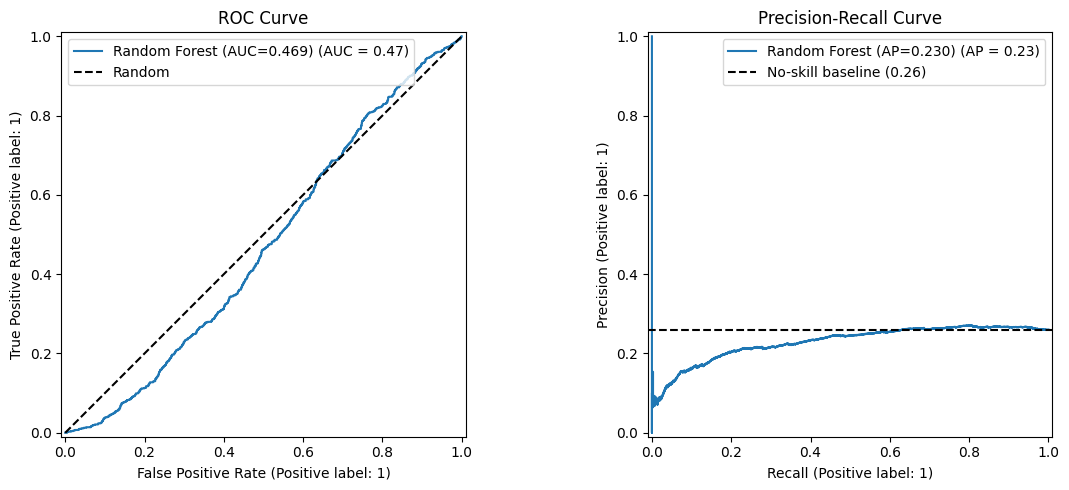

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob,
    name=f"Random Forest (AUC={roc_auc:.3f})",
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_prob,
    name=f"Random Forest (AP={pr_auc:.3f})",
    ax=axes[1],
)
axes[1].axhline(
    y_test.mean(),
    color="k",
    linestyle="--",
    label=f"No-skill baseline ({y_test.mean():.2f})"
)
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

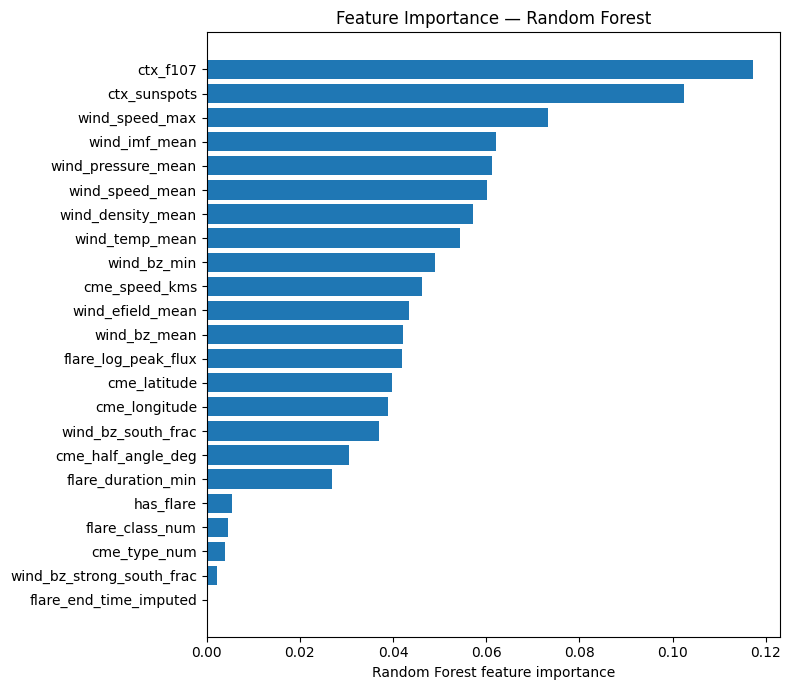


Top features:
ctx_f107              0.117157
ctx_sunspots          0.102384
wind_speed_max        0.073160
wind_imf_mean         0.062123
wind_pressure_mean    0.061297
wind_speed_mean       0.060176
wind_density_mean     0.057252
wind_temp_mean        0.054333
wind_bz_min           0.048925
cme_speed_kms         0.046244


In [11]:
# feature importance
importances = pd.Series(
    rf_pipe.named_steps["clf"].feature_importances_,
    index=FEATURE_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importances.index, importances.values)
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

print("\nTop features:")
print(importances.tail(10).iloc[::-1].to_string())

## How to Interpret the Evaluation Metrics

* **Precision** — Of all the CMEs the model predicted would cause a storm, what fraction actually did? High precision means fewer false alarms.

* **Recall** — Of all the CMEs that actually caused a storm, what fraction did the model catch? High recall means fewer missed storms.

* **F1 score** — The harmonic mean of precision and recall. It gives one score that balances false alarms and missed storms.

* **Support** — The number of actual examples in each class in the test set. This shows how many “No storm” and “Storm” cases the metrics are based on.

* **ROC-AUC** — Measures how well the model ranks storm-causing CMEs above non-storm CMEs across all possible thresholds. A score of 0.5 is random, while 1.0 is perfect.

* **PR-AUC / Average Precision** — Measures performance on the precision-recall curve. This is especially useful when the classes are imbalanced because it focuses on how well the model identifies the positive class, which is storm events. The no-skill baseline is the storm rate in the test set.

* **ROC curve** — Plots true positive rate against false positive rate at different thresholds. A better model curves closer to the top-left corner.

* **Precision-Recall curve** — Plots precision against recall at different thresholds. This is useful for seeing the tradeoff between catching storms and avoiding false alarms.

* **Random Forest feature importance** — Random Forest does not learn positive or negative coefficients like logistic regression. Instead, feature importance shows how much each feature contributed to the model’s decision splits. A higher importance value means the model used that feature more often or more effectively for prediction, but it does not tell us whether higher values of that feature increase or decrease storm probability.

## Random Forest Baseline Interpretation

The initial Random Forest baseline performed weakly on the time-based test set. The model achieved a ROC-AUC of 0.469 and a PR-AUC of 0.230, which was below the no-skill baseline of 0.260. At the default 0.50 threshold, the model predicted very few storm events and had very low storm recall.

Lowering the classification threshold improved storm recall, but it also increased the number of false positives. This suggests that the untuned Random Forest model did not generalize well to the later test period. The feature importance plot shows that the model relied most heavily on solar context variables and solar wind features, but these importance values should be interpreted cautiously because the overall model performance was weak.